# CIFAR-10: Overfitting vs Regularization

## 0. Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
import numpy as np
import matplotlib.pyplot as plt

## 1. Utility Functions

In [ ]:
def plot_history(history, title="Training Curves"):
    """Plot accuracy and loss curves for a single model."""
    epochs = range(1, len(history.history["accuracy"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history.history["accuracy"], label="Train")
    ax1.plot(epochs, history.history["val_accuracy"], label="Val")
    ax1.set_title(f"{title} — Accuracy")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
    ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, history.history["loss"], label="Train")
    ax2.plot(epochs, history.history["val_loss"], label="Val")
    ax2.set_title(f"{title} — Loss")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
    ax2.legend(); ax2.grid(True)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()


def plot_comparison(histories, names):
    """Plot accuracy and loss side-by-side for multiple models (one row per model)."""
    n = len(histories)
    fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n))
    if n == 1:
        axes = [axes]

    for i, (history, name) in enumerate(zip(histories, names)):
        epochs = range(1, len(history.history["accuracy"]) + 1)

        axes[i][0].plot(epochs, history.history["accuracy"], label="Train")
        axes[i][0].plot(epochs, history.history["val_accuracy"], label="Val")
        axes[i][0].set_title(f"{name} — Accuracy")
        axes[i][0].set_xlabel("Epoch"); axes[i][0].set_ylabel("Accuracy")
        axes[i][0].legend(); axes[i][0].grid(True)

        axes[i][1].plot(epochs, history.history["loss"], label="Train")
        axes[i][1].plot(epochs, history.history["val_loss"], label="Val")
        axes[i][1].set_title(f"{name} — Loss")
        axes[i][1].set_xlabel("Epoch"); axes[i][1].set_ylabel("Loss")
        axes[i][1].legend(); axes[i][1].grid(True)

    plt.suptitle("Model Comparison", fontsize=15, fontweight="bold")
    plt.tight_layout(); plt.show()


def print_summary(histories, names):
    """Print a summary table of final train/val accuracy and the gap."""
    col = 14
    print("=" * (28 + col * len(names)))
    print(f"{'Metric':<28}" + "".join(f"{n:>{col}}" for n in names))
    print("=" * (28 + col * len(names)))
    rows = {
        "Train Accuracy":  [h.history["accuracy"][-1] for h in histories],
        "Val   Accuracy":  [h.history["val_accuracy"][-1] for h in histories],
        "Gap (Train-Val)": [h.history["accuracy"][-1] - h.history["val_accuracy"][-1] for h in histories],
    }
    for label, values in rows.items():
        print(f"{label:<28}" + "".join(f"{v:>{col}.4f}" for v in values))
    print("=" * (28 + col * len(names)))

## 2. Load Data

Load **10,000 training samples** from CIFAR-10.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train: (10000, 32, 32, 3)  |  Test: (10000, 32, 32, 3)


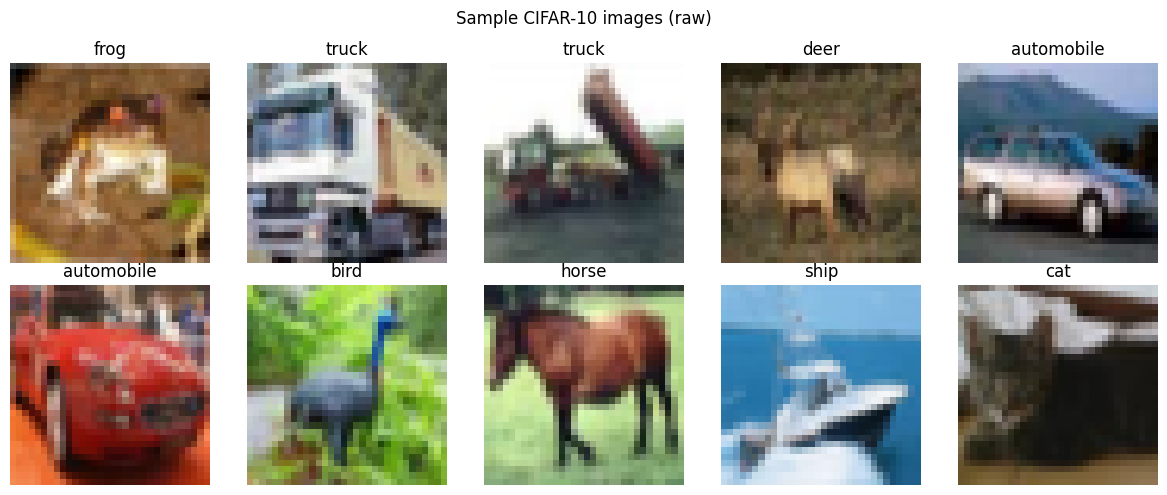

In [ ]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

N = 10000
x_train = x_train_full[:N]
y_train = y_train_full[:N]

print(f"Train: {x_train.shape}  |  Test: {x_test.shape}")

class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i][0]])
    ax.axis("off")
plt.suptitle("Sample CIFAR-10 images (raw)")
plt.tight_layout()
plt.show()

## 3. ImageDataGenerator — No Augmentation (for Overfit Model)

Rescales pixel values to [0, 1]. No flips or shifts — so the model sees the exact same images every epoch, which helps it memorise them.

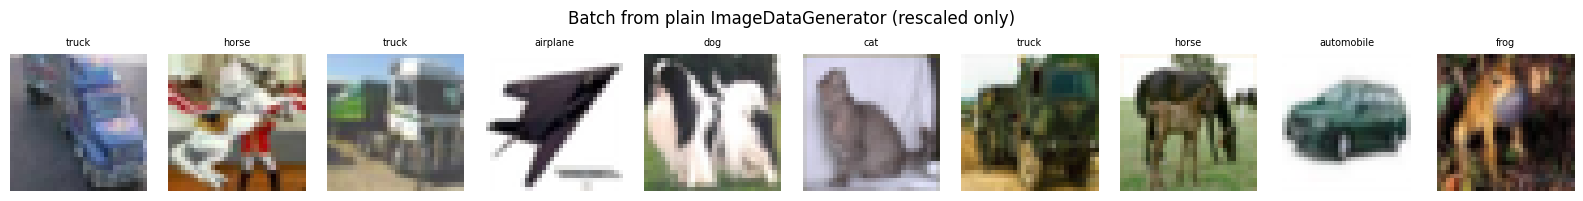

In [ ]:
plain_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = plain_datagen.flow(x_train, y_train, batch_size=64, seed=42)
test_gen  = plain_datagen.flow(x_test,  y_test,  batch_size=64, seed=42, shuffle=False)

batch_imgs, batch_labels = next(plain_datagen.flow(x_train, y_train, batch_size=10))
fig, axes = plt.subplots(1, 10, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(batch_imgs[i])
    ax.set_title(class_names[int(batch_labels[i][0])], fontsize=7)
    ax.axis("off")
plt.suptitle("Batch from plain ImageDataGenerator (rescaled only)")
plt.tight_layout()
plt.show()

## 4. Deep Overfit CNN

- More layers guarantess more capacity, which will be easier to memorise 10,000 samples.
- Batch Normalization is applied for the  activations between layers, preventing vanishing/exploding gradients in deep networks — but it does **not** regularize like Dropout or L2, so the model still overfits.
- No augmentation is applied



In [ ]:
def make_overfit_model():
    return keras.Sequential([
        keras.layers.Input(shape=(32, 32, 3)),

        # Block 1
        keras.layers.Conv2D(64, 3, padding="same"), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.Conv2D(64, 3, padding="same"), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.MaxPooling2D(),                 

        # Block 2
        keras.layers.Conv2D(128, 3, padding="same"), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.Conv2D(128, 3, padding="same"), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.MaxPooling2D(),                  

        # Block 3
        keras.layers.Conv2D(256, 3, padding="same"), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.Conv2D(256, 3, padding="same"), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.Conv2D(256, 3, padding="same"), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.MaxPooling2D(),                  

        # Block 4
        keras.layers.Conv2D(512, 3, padding="same"), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.Conv2D(512, 3, padding="same"), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),

        # Classifier
        keras.layers.Flatten(),
        keras.layers.Dense(2048, activation="relu"),
        keras.layers.Dense(1024, activation="relu"),
        keras.layers.Dense(10,   activation="softmax"),
    ], name="overfit_cnn")

overfit_model = make_overfit_model()
overfit_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
overfit_model.summary()

Model: "overfit_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,02

 Total params: 24,171,850 (92.21 MB)

 Trainable params: 24,167,498 (92.19 MB)

 Non-trainable params: 4,352 (17.00 KB)

In [6]:
EPOCHS = 50

overfit_history = overfit_model.fit(
    train_gen,
    epochs=EPOCHS,
    steps_per_epoch=len(x_train) // 64,
    validation_data=(x_test.astype("float32") / 255.0, y_test),
    verbose=1,
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


156/156 ━━━━━━━━━━━━━━━━━━━━ 34s 112ms/step - accuracy: 0.1370 - loss: 4.0206 - val_accuracy: 0.1009 - val_loss: 2.7925
Epoch 2/50
  1/156 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.1875 - loss: 2.0568

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1875 - loss: 2.0568 - val_accuracy: 0.1008 - val_loss: 2.8360
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.2490 - loss: 1.8897 - val_accuracy: 0.1073 - val_loss: 4.1525
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4219 - loss: 1.4748 - val_accuracy: 0.1010 - val_loss: 4.4089
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.3542 - loss: 1.6734 - val_accuracy: 0.1997 - val_loss: 2.7622
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3906 - loss: 1.4441 - val_accuracy: 0.2014 - val_loss: 2.7418
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.4465 - loss: 1.4884 - val_accuracy: 0.2742 - val_loss: 2.3177
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5156 - loss: 1.3396 - val_accuracy: 0.2633 - val_loss: 2.4992
Epoch 9/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.4854 - loss: 1.3724 - val_accuracy: 0.235

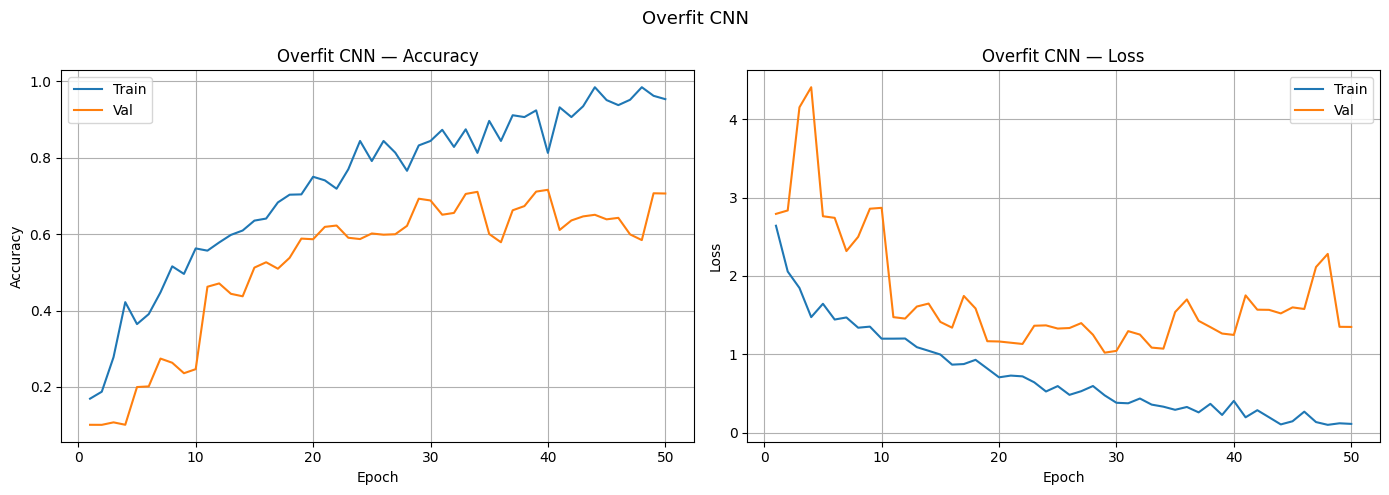

In [7]:
plot_history(overfit_history, title="Overfit CNN")

### Overfit CNN — Observations

The deep CNN (11 conv layers, no regularization) was trained for the full **50 epochs** on **10,000 samples**.

| Metric | Value |
|---|---|
| Final Train Accuracy | **95.31%** |
| Final Val Accuracy | **70.62%** |
| Gap (Train − Val) | **24.69%** |
| Model Parameters | **24.2M** |

- Training accuracy climbed steadily toward ~95%, while validation accuracy fluctuated around 58–70% without converging — so it is an overfitting signature.
- The 24.69% gap confirms the model **memorised the 10,000 training images** rather than learning generalizable features.
- **BatchNormalization** kept gradient flow stable throughout all 50 epochs, enabling fast convergence on the training set — but it does not act as a regularizer, so memorization was not prevented.


## 5. ImageDataGenerator — With Augmentation (for Regularized Model)

Augmentation expands the 10,000-sample training set by producing different views of each image every epoch, directly combating memorization.

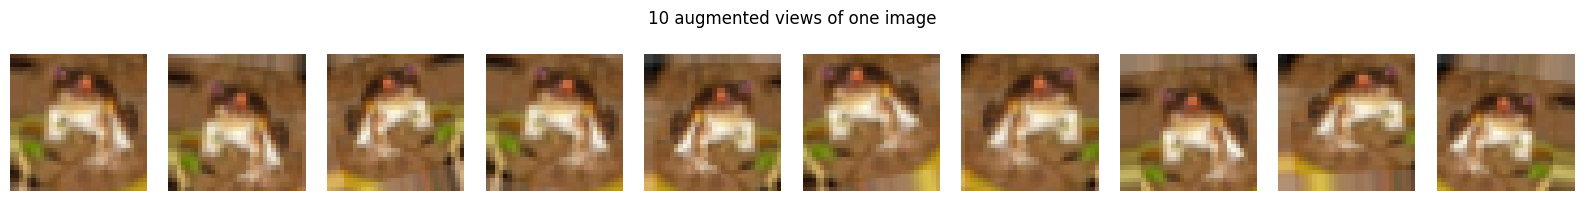

In [ ]:
aug_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)

aug_train_gen = aug_datagen.flow(x_train, y_train, batch_size=64, seed=42)

sample_img = x_train[0:1]
aug_iter   = aug_datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(1, 10, figsize=(16, 2))
for ax in axes:
    ax.imshow(next(aug_iter)[0])
    ax.axis("off")
plt.suptitle("10 augmented views of one image")
plt.tight_layout()
plt.show()

## 6. Regularized CNN

Same depth as the overfit model, but now with:
- **He Normal initializer** — optimal weight initialization for ReLU activations
- **BatchNormalization** — stable gradients throughout the deep network
- **Reduced Dropout** — `0.1` after conv blocks, `0.3` after the dense layer
- **L2 weight decay** — penalises large weights to keep the model from overfitting
- **Global Average Pooling** — replaces `Flatten + Dense(2048)`, as mention in your notebook it improves generalization by cuting down the number of learnable parameters
- **Data augmentation** — model sees different views of each image every epoch
- **ReduceLROnPlateau** — halves the learning rate whenever `val_loss` stops improving for 5 epochs (min LR: 1e-6)
- **Early Stopping** — stops training when `val_loss` shows no improvement for 10 epochs, restores best weights

In [ ]:
l2_reg = regularizers.l2(1e-4)
he_normal = keras.initializers.HeNormal()

def make_regularized_model():
    return keras.Sequential([
        keras.layers.Input(shape=(32, 32, 3)),

        # Block 1
        keras.layers.Conv2D(64, 3, padding="same", kernel_initializer=he_normal, kernel_regularizer=l2_reg), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.Conv2D(64, 3, padding="same", kernel_initializer=he_normal, kernel_regularizer=l2_reg), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.MaxPooling2D(),
        keras.layers.Dropout(0.1),

        # Block 2
        keras.layers.Conv2D(128, 3, padding="same", kernel_initializer=he_normal, kernel_regularizer=l2_reg), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.Conv2D(128, 3, padding="same", kernel_initializer=he_normal, kernel_regularizer=l2_reg), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.MaxPooling2D(),
        keras.layers.Dropout(0.1),

        # Block 3
        keras.layers.Conv2D(256, 3, padding="same", kernel_initializer=he_normal, kernel_regularizer=l2_reg), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.Conv2D(256, 3, padding="same", kernel_initializer=he_normal, kernel_regularizer=l2_reg), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.Conv2D(256, 3, padding="same", kernel_initializer=he_normal, kernel_regularizer=l2_reg), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.MaxPooling2D(),
        keras.layers.Dropout(0.1),

        # Block 4
        keras.layers.Conv2D(512, 3, padding="same", kernel_initializer=he_normal, kernel_regularizer=l2_reg), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.Conv2D(512, 3, padding="same", kernel_initializer=he_normal, kernel_regularizer=l2_reg), keras.layers.BatchNormalization(), keras.layers.Activation("relu"),
        keras.layers.Dropout(0.1),

        # Global Average Pooling
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(1024, activation="relu", kernel_initializer=he_normal, kernel_regularizer=l2_reg),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(10, activation="softmax"),
    ], name="regularized_cnn")

reg_model = make_regularized_model()
reg_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
reg_model.summary()

Model: "regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 8, 8, 256)      │             

 Total params: 5,819,722 (22.20 MB)

 Trainable params: 5,815,370 (22.18 MB)

 Non-trainable params: 4,352 (17.00 KB)

In [ ]:
EPOCHS = 100

early_stop_reg = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,      
    patience=5,
    min_lr=1e-6,
    verbose=1,
)

reg_history = reg_model.fit(
    aug_train_gen,
    epochs=EPOCHS,
    steps_per_epoch=len(x_train) // 64,
    validation_data=(x_test.astype("float32") / 255.0, y_test),
    callbacks=[early_stop_reg, lr_scheduler],
    verbose=1,
)

Epoch 1/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 38s 148ms/step - accuracy: 0.2785 - loss: 2.6662 - val_accuracy: 0.3061 - val_loss: 2.9041 - learning_rate: 0.0010
Epoch 2/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4688 - loss: 1.9817 - val_accuracy: 0.2496 - val_loss: 3.7164 - learning_rate: 0.0010
Epoch 3/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.4343 - loss: 2.1271 - val_accuracy: 0.3513 - val_loss: 3.1365 - learning_rate: 0.0010
Epoch 4/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5625 - loss: 1.8876 - val_accuracy: 0.3737 - val_loss: 2.9366 - learning_rate: 0.0010
Epoch 5/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - accuracy: 0.4980 - loss: 1.9037 - val_accuracy: 0.2660 - val_loss: 3.7029 - learning_rate: 0.0010
Epoch 6/100
  1/156 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.5469 - loss: 1.6959
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5469 -

### Regularized CNN — Observations

The regularized model used early stopping (patience=10) and ReduceLROnPlateau (patience=5). It stopped at **epoch 59**, with the LR reduced at epoch 59 to ~7.8e-6, and restored the best weights from **epoch 49**.

| Metric | Value |
|---|---|
| Final Train Accuracy | **88.52%** |
| Final Val Accuracy | **79.29%** |
| Gap (Train − Val) | **9.23%** |
| Model Parameters | **5.8M** (vs 24.2M overfit) |

- Val accuracy improved from **70.62% → 79.29%** — a gain of **+8.67 pp** over the overfit model, despite having 4x fewer parameters.
- The train-val gap dropped from **24.69% → 9.23%** — a **63% reduction** in overfitting. Each technique contributed:
- **Global Average Pooling** — replaced `Flatten + Dense(2048)` and cut ~18M parameters (24M → 5.8M). Fewer parameters means far less capacity for memorization, and the spatial averaging acts as a built-in regularizer.
- **Reduced Dropout** — prevent co-adaptation of neurons.
- **L2 weight decay** — penalized large weights, keeping predictions robust across unseen samples.
- **He Normal initializer** — weights started in the optimal range for ReLU, giving faster and more stable early convergence.
- **Data augmentation** — the model never saw the same image twice, effectively expanding the dataset and making memorization much harder.
- **ReduceLROnPlateau** triggered at epoch 59, halving the LR to ~7.8e-6. This confirms the model had already extracted most of the signal it could at the initial LR.
- **Early stopping** correctly identified epoch 49 as the best checkpoint and prevented further overfitting in later epochs.

## 7. Side-by-Side Comparison

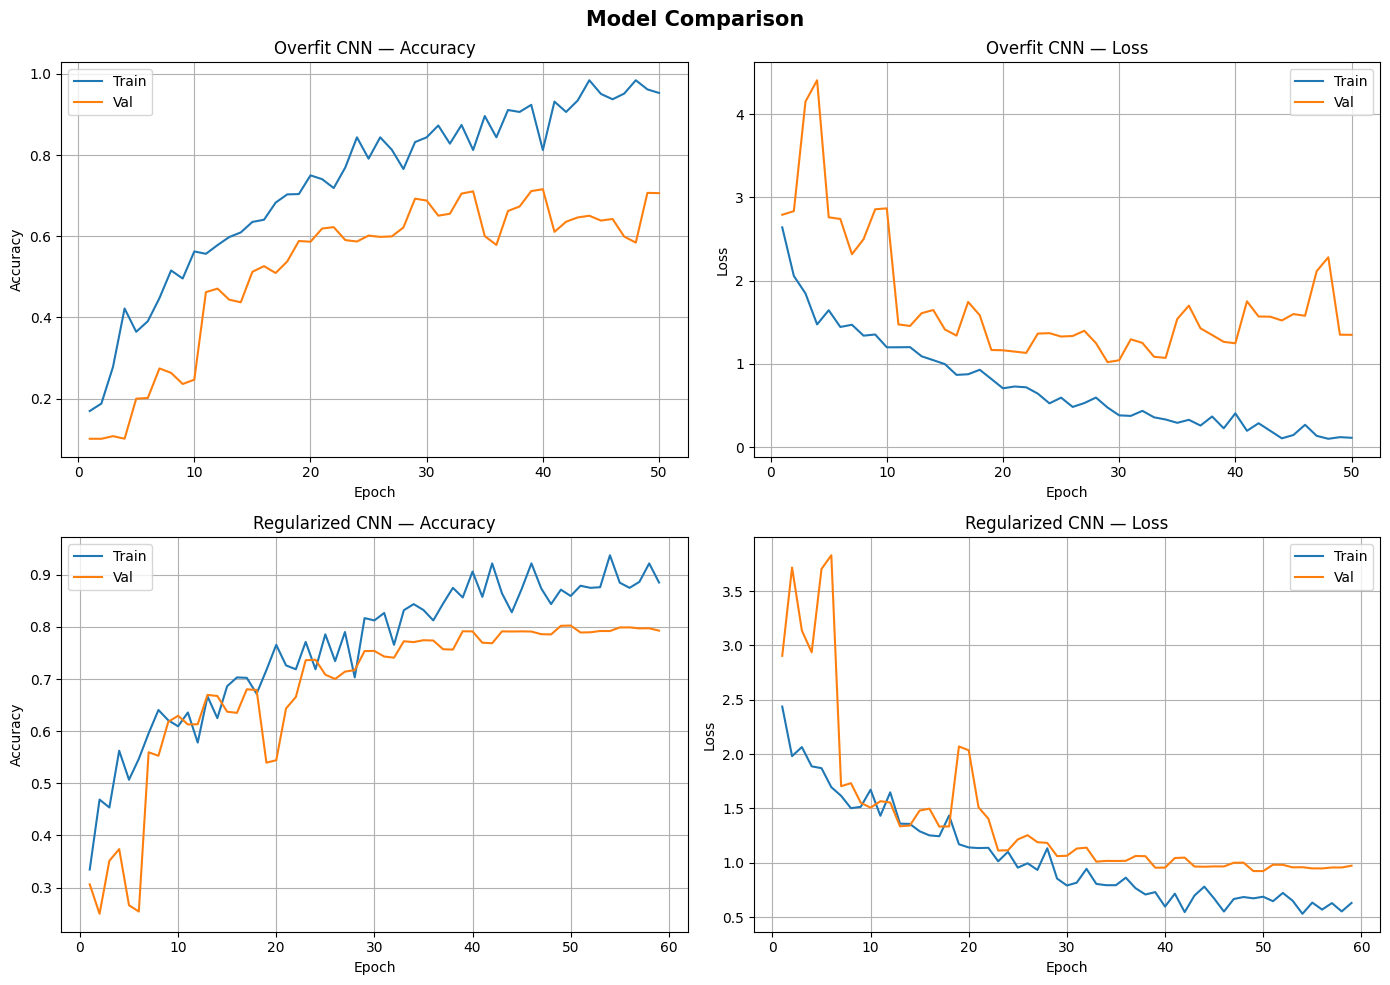

Metric                         Overfit CNNRegularized CNN
Train Accuracy                      0.9531        0.8852
Val   Accuracy                      0.7062        0.7929
Gap (Train-Val)                     0.2469        0.0923


In [11]:
plot_comparison(
    histories=[overfit_history, reg_history],
    names=["Overfit CNN", "Regularized CNN"],
)

print_summary(
    histories=[overfit_history, reg_history],
    names=["Overfit CNN", "Regularized CNN"],
)

---

## Final Conclusion

| Metric | Overfit CNN | Regularized CNN |
|---|---|---|
| Train Accuracy | 95.31% | 88.52% |
| Val Accuracy | 70.62% | **79.29%** |
| Gap (Train − Val) | **24.69%** | **9.23%** |
| Parameters | 24.2M | 5.8M |
| Epochs Trained | 50 (full) | 59 (early stopped, best: ep. 49) |
| Augmentation | No | Yes |
| Dropout | No | Yes (0.1 / 0.3) |
| L2 Regularization | No | Yes (1e-4) |
| Weight Initializer | Default | He Normal |
| Classifier Head | Flatten + Dense(2048+1024) | GAP + Dense(1024) |
| LR Scheduling | No | ReduceLROnPlateau |

**Conclusions:**

1. **Capacity alone causes memorization.** The 24M-parameter overfit CNN hit 95% train accuracy but only 70% val accuracy. The 24.69% gap is not a sign of a powerful model — it is a sign of a model that overfitts the dataset instead of the underlying patterns.

2. **Global Average Pooling was the most impactful single change.** Replacing `Flatten + Dense(2048)` with GAP cut 18M parameters (24M --> 5.8M) and raised val accuracy. The regularized model achieves better generalization with **4x fewer parameters**.

3. **Regularization trades train accuracy for generalization.** Train accuracy dropped from 95% --> 88%, but val accuracy rose from 70% --> 79%. The smaller gap (9.23% vs 24.69%) indicates a real success metric — the model is learning the task, not memorising the dataset.

---